<a href="https://colab.research.google.com/github/ajgquional/classical-ml-experiments/blob/main/autoencoder_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder: Fisher Iris Data

In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from time import time

# scikit-learn
from sklearn import datasets # for importing iris dataset
from sklearn.decomposition import PCA # for implementation of PCA
from sklearn.model_selection import train_test_split # for data splitting

# tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# loading iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# splitting data into 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)

# reducing data into 2 principal components using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train,y_train)
X_test_pca = pca.transform(X_test)
X_pca = np.vstack((X_train_pca,X_test_pca))

# checking the shapes of X_train and X_test
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (105, 4)
X_test shape: (45, 4)


In [ ]:
# reducing data via autoencoder

# defining the architecture
# from 4 dimensions to 2 dimensions
encoder = Sequential([Dense(4, input_shape=[4], activation='relu'), # 4 input neurons
                      Dense(2, input_shape=[4])], name="encoder") # 2 output neurons, linear activation
# from 2 dimensions to 4 dimensions
decoder = Sequential([Dense(4, input_shape=[2], activation='relu'), # 4 input neurons
                      Dense(4, input_shape=[4])], name="decoder") # 4 output neurons, linear activation

# stacking the encoder and decoder into one
autoencoder = Sequential([encoder, decoder], name="autoencoder")

# printing a summary of the architecture
autoencoder.summary()

# compiling the architecture
autoencoder.compile(loss='mse', optimizer=Adam(learning_rate=0.001))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder (Sequential)                 │ (None, 2)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Sequential)                 │ (None, 4)                   │              32 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62 (248.00 B)

 Trainable params: 62 (248.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fitting the autoencoder and timing the execution time
start = time()
history = autoencoder.fit(X_train, X_train, epochs=1000)
end = time() - start

print(f"\nExecution time: {end} sec")

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 19.4933
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.8065 
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 18.4855
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 19.0726
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 18.6198
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 18.1040
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 17.7009
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 17.9876
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 17.5733
Epoch 10/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17.0788
Epoch 11/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.6586
Epoch 12/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.0147 
Epoch 13/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.7421 
Epoch 14/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.7040 
Epoch 15/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - los

In [ ]:
# reducing the dimensions of the training and test data via the trained encoder
X_train_sae = encoder.predict(X_train)
X_test_sae = encoder.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


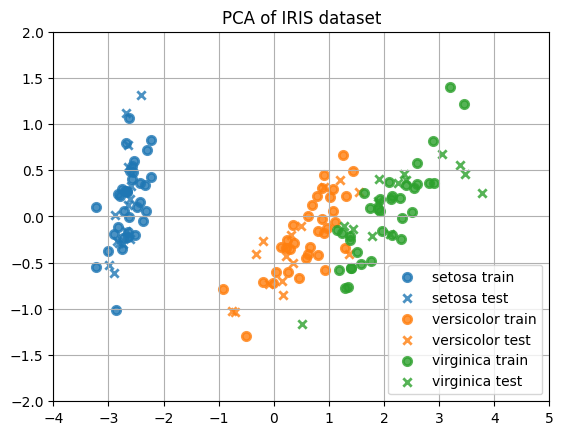

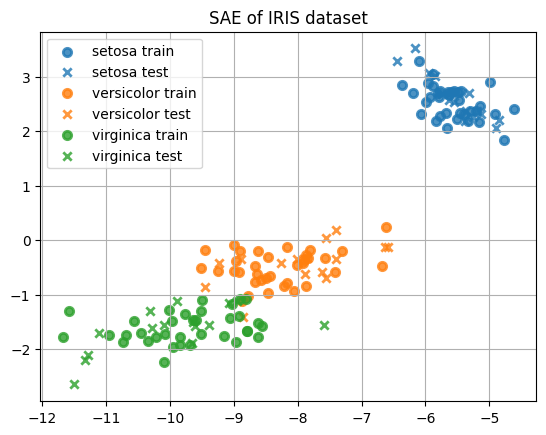

In [ ]:
# visualizing the reduced training and test data
def visual(X_train, y_train, X_test, y_test):
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # blue, orange, green

    for color, i, target_name in zip(colors, [0, 1, 2], target_names):
        # plotting training data
        plt.scatter(X_train[y_train == i, 0], X_train[y_train == i, 1],
                    color=color, alpha=0.8, lw=2, label=f"{target_name} train")

        # plotting test data
        plt.scatter(X_test[y_test == i, 0], X_test[y_test == i, 1],
                    color=color, alpha=0.8, lw=2, label=f"{target_name} test", marker='x')

# visualizing PCA-reduced data
visual(X_train_pca, y_train, X_test_pca, y_test)
plt.axis([-4, 5, -2, 2])
plt.legend(loc="best", shadow=False)
plt.title("PCA of IRIS dataset")
plt.grid()
plt.show()

# visualizing autoencoder-reduced data
visual(X_train_sae, y_train, X_test_sae, y_test)
plt.legend(loc="best", shadow=False)
plt.title("SAE of IRIS dataset")
plt.grid()
plt.show()